<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Jord%C3%A0%2C%20%C3%92.%2C%20Knoll%2C%20K.%2C%20Kuvshinov%2C%20D.%2C%20Schularick%2C%20M.%2C%20%26%20Taylor%2C%20A.%20M.%20(2019).%20%20The%20rate%20of%20return%20on%20everything%2C%201870%E2%80%932015/Rate_of_Return_on_Everything.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The data I used for this was from the file "rore_public_main.dta."

In [1]:
from google.colab import files
#uploaded = files.upload()

In [2]:
import pandas as pd

df = pd.read_stata("rore_public_main.dta")
print(df.head())

   iso    country       year     eq_tr  housing_tr  bond_tr  bill_rate  \
0  AUS  Australia 1870-01-01 -0.004904         NaN      NaN     0.0488   
1  AUS  Australia 1871-01-01  0.110193         NaN      NaN     0.0460   
2  AUS  Australia 1872-01-01  0.176749         NaN      NaN     0.0460   
3  AUS  Australia 1873-01-01  0.151686         NaN      NaN     0.0440   
4  AUS  Australia 1874-01-01  0.191481         NaN      NaN     0.0450   

   rent_ipolated  prices_ipolated  housing_capgain  ...     eq_dp  \
0            NaN              NaN              NaN  ...  0.071417   
1            NaN              NaN        -0.045456  ...  0.065466   
2            NaN              NaN         0.031747  ...  0.062997   
3            NaN              NaN        -0.030770  ...  0.064484   
4            NaN              NaN         0.206350  ...  0.063503   

   eq_capgain_interp  eq_tr_interp  eq_dp_interp  ccode  bond_rate  \
0                NaN           NaN           NaN    1.0   0.049118   


In [3]:
print(df.columns)

Index(['iso', 'country', 'year', 'eq_tr', 'housing_tr', 'bond_tr', 'bill_rate',
       'rent_ipolated', 'prices_ipolated', 'housing_capgain',
       'housing_rent_rtn', 'housing_rent_yd', 'eq_capgain', 'eq_dp',
       'eq_capgain_interp', 'eq_tr_interp', 'eq_dp_interp', 'ccode',
       'bond_rate', 'eq_div_rtn', 'capital_tr', 'risky_tr', 'safe_tr'],
      dtype='object')


In [4]:
df['year'] = pd.to_datetime(df['year']).dt.year

# Drop rows missing all return columns
df = df.dropna(subset=['eq_tr', 'housing_tr', 'bond_tr', 'bill_rate'], how='all')

print(df.shape)
print(df['country'].unique())
print(df['year'].min(), df['year'].max())
df.head()

(2329, 23)
['Australia' 'Belgium' 'Denmark' 'Finland' 'France' 'Germany' 'Italy'
 'Japan' 'Netherlands' 'Norway' 'Portugal' 'Spain' 'Sweden' 'Switzerland'
 'UK' 'USA']
1870 2015


,iso,country,year,eq_tr,housing_tr,bond_tr,bill_rate,rent_ipolated,prices_ipolated,housing_capgain,...,eq_dp,eq_capgain_interp,eq_tr_interp,eq_dp_interp,ccode,bond_rate,eq_div_rtn,capital_tr,risky_tr,safe_tr
0,AUS,Australia,1870,-0.004904,NaN,NaN,0.0488,NaN,NaN,NaN,...,0.071417,NaN,NaN,NaN,1.0,0.049118,0.066415,NaN,NaN,NaN
1,AUS,Australia,1871,0.110193,NaN,NaN,0.0460,NaN,NaN,-0.045456,...,0.065466,NaN,NaN,NaN,1.0,0.048446,0.068193,NaN,NaN,NaN
2,AUS,Australia,1872,0.176749,NaN,NaN,0.0460,NaN,NaN,0.031747,...,0.062997,NaN,NaN,NaN,1.0,0.047373,0.069861,NaN,NaN,NaN
3,AUS,Australia,1873,0.151686,NaN,NaN,0.0440,NaN,NaN,-0.030770,...,0.064484,NaN,NaN,NaN,1.0,0.046720,0.069842,NaN,NaN,NaN
4,AUS,Australia,1874,0.191481,NaN,NaN,0.0450,NaN,NaN,0.206350,...,0.063503,NaN,NaN,NaN,1.0,0.046533,0.071085,NaN,NaN,NaN


In [5]:
cols = ['eq_tr', 'housing_tr', 'bond_tr', 'bill_rate']

df_clean = df.copy()
for col in cols:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

In [6]:
assets = {
    'Equity': 'eq_tr',
    'Housing': 'housing_tr',
    'Bonds': 'bond_tr',
    'Bills': 'bill_rate'
}

rows = []
for label, col in assets.items():
    s = df_clean[col].dropna()  # <-- df_clean, not df
    rows.append({
        'Asset': label,
        'Mean (%)': round(s.mean() * 100, 2),
        'Std Dev (%)': round(s.std() * 100, 2),
        'Sharpe': round((s.mean() - df_clean['bill_rate'].mean()) / s.std(), 2),
        'Min (%)': round(s.min() * 100, 2),
        'Max (%)': round(s.max() * 100, 2),
        'N': s.count()
    })

summary = pd.DataFrame(rows).set_index('Asset')
print(summary.to_string())

         Mean (%)  Std Dev (%)  Sharpe  Min (%)  Max (%)     N
Asset                                                         
Equity      10.80        21.59    0.29   -36.09    94.69  2183
Housing     10.81         9.52    0.66   -10.96    43.59  1829
Bonds        5.97         7.92    0.18   -12.84    33.06  2215
Bills        4.51         2.90    0.00     0.05    15.43  2272


This table summarizes how different asset classes performed over time by showing their average returns, risk, and extremes. Housing delivered relatively strong and stable performance, with an average return of about 10.9% and a high Sharpe ratio, meaning good returns for the level of risk. Bonds and bills were safer but offered lower returns, with bonds around 6% and bills around 4.5%. Overall, the table shows the trade-off between risk and return, where safer assets have lower returns while riskier ones can offer higher gains.


In [7]:
periods = {
    'Full sample (1870–2015)': (1870, 2015),
    'Pre-WW1 (1870–1913)':     (1870, 1913),
    'Interwar (1919–1939)':    (1919, 1939),
    'Post-WW2 (1950–1980)':    (1950, 1980),
    'Modern (1980–2015)':      (1980, 2015),
}

rows = []
for period, (y0, y1) in periods.items():
    sub = df_clean[(df_clean['year'] >= y0) & (df_clean['year'] <= y1)]  # <-- df_clean
    row = {'Period': period}
    for label, col in assets.items():
        row[f'{label} mean'] = round(sub[col].mean() * 100, 2)
    row['Equity premium'] = round((sub['eq_tr'].mean() - sub['bill_rate'].mean()) * 100, 2)
    row['Housing premium'] = round((sub['housing_tr'].mean() - sub['bill_rate'].mean()) * 100, 2)
    rows.append(row)

pd.DataFrame(rows).set_index('Period')

,Equity mean,Housing mean,Bonds mean,Bills mean,Equity premium,Housing premium
Period,,,,,,
Full sample (1870–2015),10.80,10.81,5.97,4.51,6.29,6.30
Pre-WW1 (1870–1913),7.11,7.96,4.55,3.95,3.16,4.01
Interwar (1919–1939),8.34,7.88,6.25,4.07,4.28,3.81
Post-WW2 (1950–1980),11.88,14.70,4.60,5.28,6.60,9.42
Modern (1980–2015),14.58,10.18,9.24,5.55,9.03,4.63


In [8]:
# Step 1: diagnose the problem
print(df_clean[['year', 'country', 'eq_tr']].nlargest(10, 'eq_tr'))
print(df_clean[['year', 'country', 'eq_tr']].nsmallest(10, 'eq_tr'))

     year  country     eq_tr
216  1940  Belgium  0.946948
513  1945  Finland  0.946948
567  1999  Finland  0.946948
668  1954   France  0.946948
781  1921  Germany  0.946948
782  1922  Germany  0.946948
783  1923  Germany  0.946948
786  1926  Germany  0.946948
809  1949  Germany  0.946948
811  1951  Germany  0.946948
     year    country     eq_tr
138  2008  Australia -0.360909
284  2008    Belgium -0.360909
430  2008    Denmark -0.360909
576  2008    Finland -0.360909
722  2008     France -0.360909
808  1948    Germany -0.360909
862  2002    Germany -0.360909
868  2008    Germany -0.360909
932  1926      Italy -0.360909
951  1945      Italy -0.360909


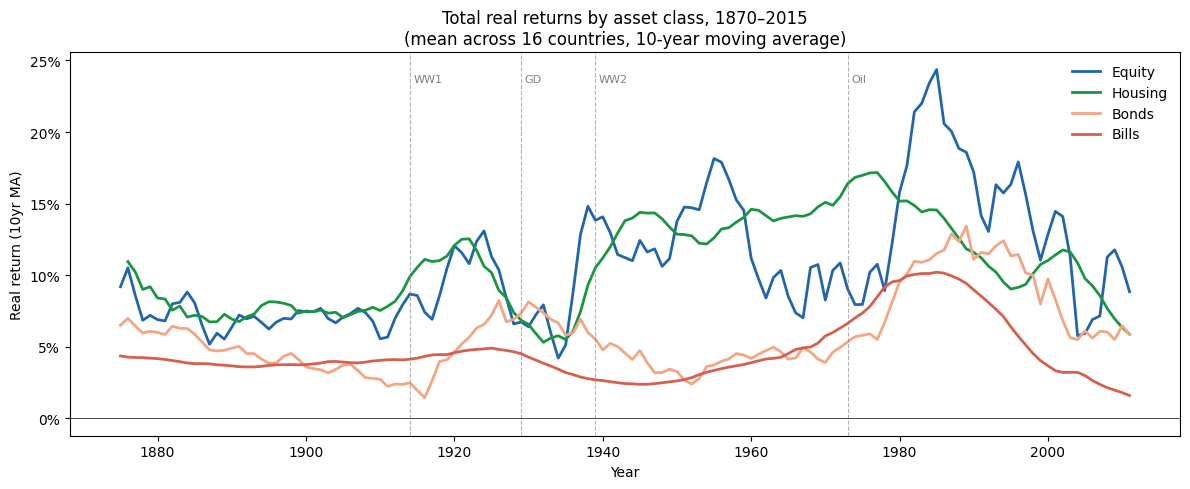

In [9]:
# Step 2: clip extreme values before plotting (winsorize at 1st/99th percentile)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


annual = df_clean.groupby('year')[cols].mean()
smooth = annual.rolling(10, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(smooth.index, smooth['eq_tr'],      label='Equity',  color='#2166ac', lw=2)
ax.plot(smooth.index, smooth['housing_tr'], label='Housing', color='#1a9641', lw=2)
ax.plot(smooth.index, smooth['bond_tr'],    label='Bonds',   color='#f4a582', lw=2)
ax.plot(smooth.index, smooth['bill_rate'],  label='Bills',   color='#d6604d', lw=2)

for yr, label in [(1914,'WW1'), (1929,'GD'), (1939,'WW2'), (1973,'Oil')]:
    ax.axvline(yr, color='gray', lw=0.8, linestyle='--', alpha=0.6)
    ax.text(yr+0.5, ax.get_ylim()[1]*0.92, label, fontsize=8, color='gray')

ax.axhline(0, color='black', lw=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Year')
ax.set_ylabel('Real return (10yr MA)')
ax.set_title('Total real returns by asset class, 1870–2015\n(mean across 16 countries, 10-year moving average)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

This chart shows the 10 year moving average of real returns for equity, housing, bonds, and bills across 16 advanced economies from 1870 to 2015, and is a central result of the Jordà et al. paper.

Risky assets clearly outperform safe ones over the entire period. Equity and housing consistently exceed bonds and bills, showing that the risk premium is long standing rather than modern. Equity is highly volatile, while housing delivers similarly strong returns with much lower volatility, supporting the paper’s key claim that housing is an overlooked high return asset.

Major historical events are visible in the data. Returns fall sharply during the World Wars and the Great Depression, with equity bottoming in the late 1930s. From 1950 to 1980, both equity and housing rise steadily during postwar expansion. The 1970s oil shock briefly interrupts this trend, followed by a major equity boom in the 1980s. Since around 2000, all asset classes trend downward, with especially low returns on bills, consistent with a prolonged low interest rate environment.


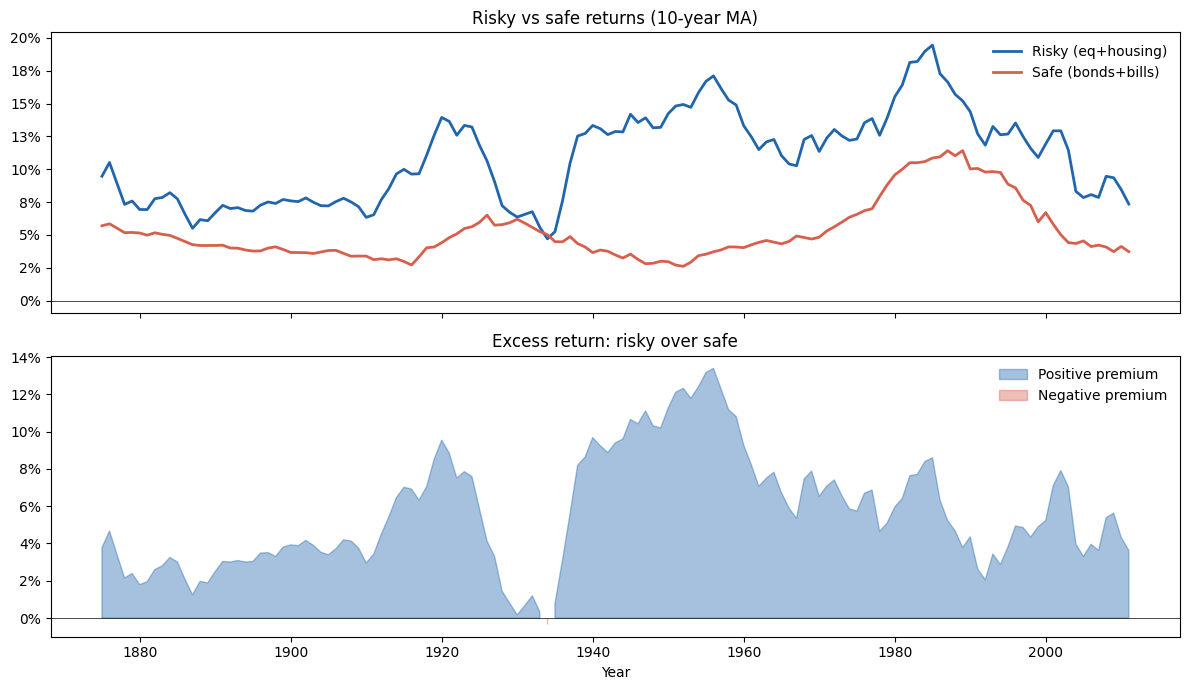

In [10]:
df_clean['risky_tr'] = df_clean[['eq_tr', 'housing_tr']].mean(axis=1)
df_clean['safe_tr']  = df_clean[['bond_tr', 'bill_rate']].mean(axis=1)

annual2 = df_clean.groupby('year')[['risky_tr', 'safe_tr']].mean()
smooth2 = annual2.rolling(10, center=True).mean()
smooth2['premium'] = smooth2['risky_tr'] - smooth2['safe_tr']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(smooth2.index, smooth2['risky_tr'], label='Risky (eq+housing)', color='#2166ac', lw=2)
axes[0].plot(smooth2.index, smooth2['safe_tr'],  label='Safe (bonds+bills)', color='#d6604d', lw=2)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].legend(frameon=False)
axes[0].set_title('Risky vs safe returns (10-year MA)')

axes[1].fill_between(smooth2.index, smooth2['premium'], 0,
                     where=smooth2['premium'] >= 0, color='#2166ac', alpha=0.4, label='Positive premium')
axes[1].fill_between(smooth2.index, smooth2['premium'], 0,
                     where=smooth2['premium'] <  0, color='#d6604d', alpha=0.4, label='Negative premium')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('Excess return: risky over safe')
axes[1].legend(frameon=False)
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

This figure compares the 10-year moving average returns of risky assets (equities and housing) versus safe assets (bonds and bills) over time, along with the excess return of risky assets over safe ones. The top panel shows that risky assets generally deliver higher returns than safe assets, though both fluctuate over the years. The bottom panel highlights the risk premium, which is the extra return investors receive for holding riskier assets. For most of the period, this premium is positive, meaning risky assets outperform safe ones. However, there are times when the premium narrows or briefly turns negative, indicating periods when risky assets underperform relative to safe assets. Overall, the graph illustrates the long-term advantage of investing in risky assets, while also capturing periods of relative underperformance that investors may face.


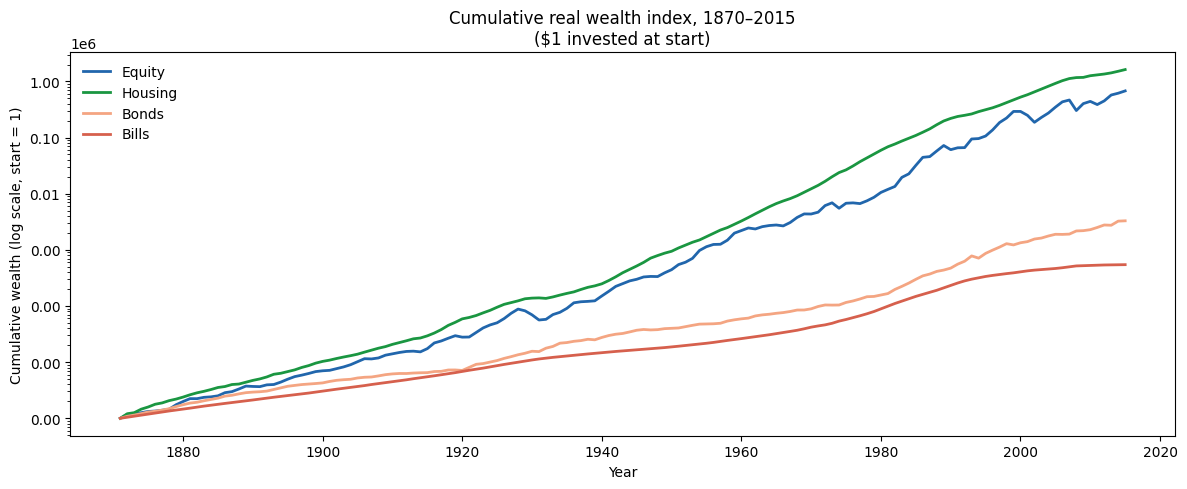

In [11]:
annual_all = df_clean.groupby('year')[['eq_tr','housing_tr','bond_tr','bill_rate']].mean().dropna()
cum = (1 + annual_all).cumprod()
cum = cum / cum.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum.index, cum['eq_tr'],      label='Equity',  color='#2166ac', lw=2)
ax.plot(cum.index, cum['housing_tr'], label='Housing', color='#1a9641', lw=2)
ax.plot(cum.index, cum['bond_tr'],    label='Bonds',   color='#f4a582', lw=2)
ax.plot(cum.index, cum['bill_rate'],  label='Bills',   color='#d6604d', lw=2)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.set_ylabel('Cumulative wealth (log scale, start = 1)')
ax.set_xlabel('Year')
ax.set_title('Cumulative real wealth index, 1870–2015\n($1 invested at start)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

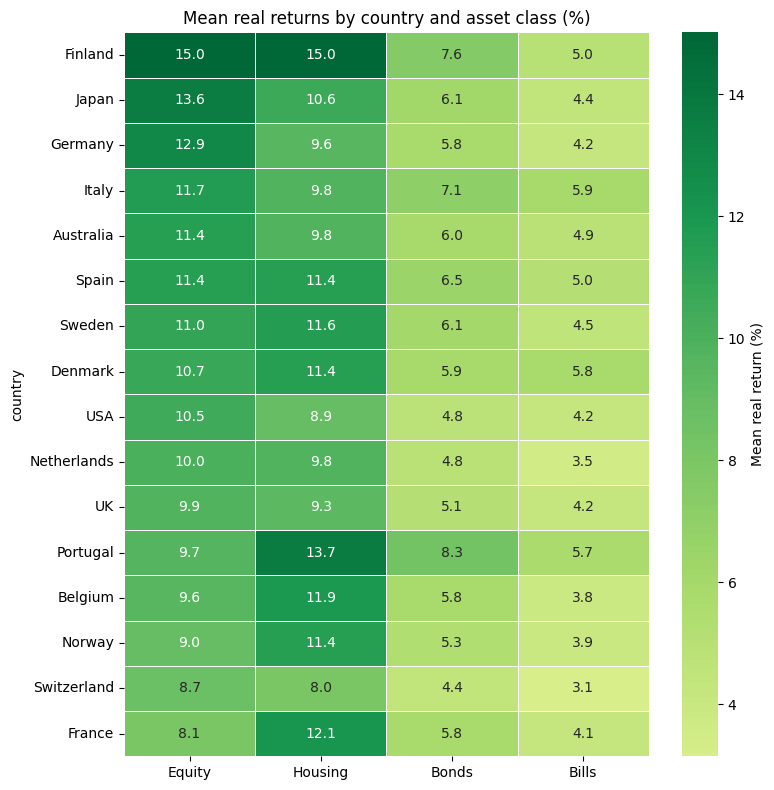

In [12]:
import seaborn as sns

country_means = df_clean.groupby('country')[['eq_tr','housing_tr','bond_tr','bill_rate']].mean() * 100
country_means.columns = ['Equity','Housing','Bonds','Bills']
country_means = country_means.sort_values('Equity', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(country_means, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean real return (%)'})
ax.set_title('Mean real returns by country and asset class (%)')
plt.tight_layout()
plt.show()

This heatmap shows average annual real returns for equity, housing, bonds, and bills across 16 advanced economies from 1870 to 2015, with countries ranked by equity performance.

Housing stands out as consistently strong. In most countries, it matches or even exceeds equity returns. Portugal and France are especially notable, where housing clearly outperforms equity. This supports the paper’s key point that housing has been an overlooked asset, offering high returns with lower volatility.

In contrast, bonds and bills cluster in a narrower, lower range with much less variation across countries. The visual pattern makes clear that the gap between risky and safe assets is consistent across all economies in the sample, not just driven by any single country.


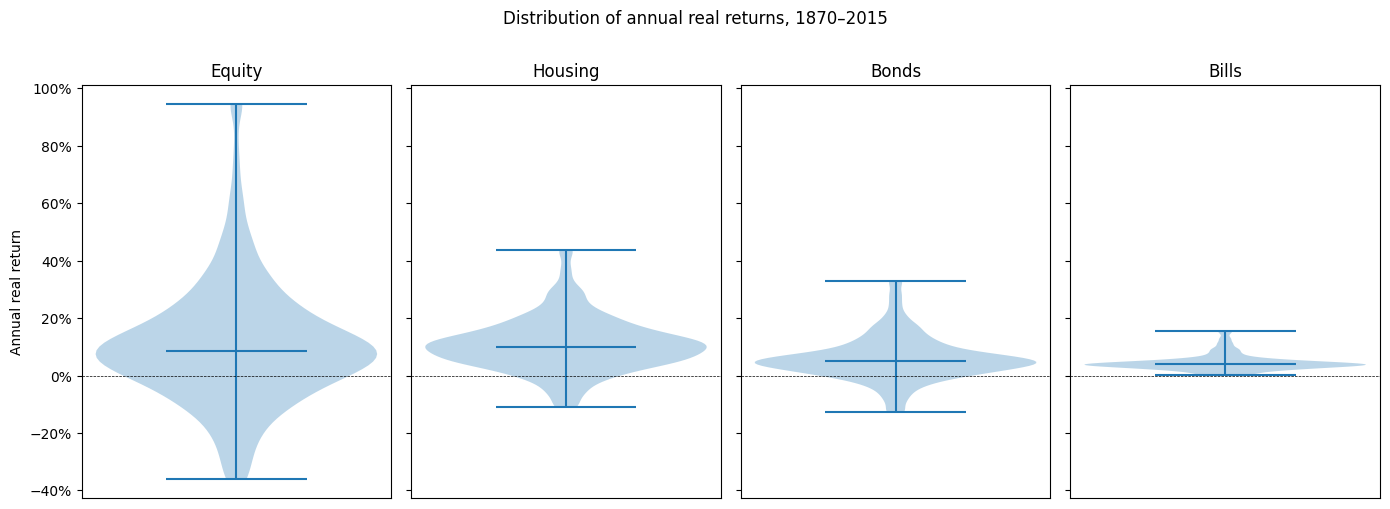

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)

for ax, (label, col) in zip(axes, [('Equity','eq_tr'),('Housing','housing_tr'),
                                    ('Bonds','bond_tr'),('Bills','bill_rate')]):
    data = df_clean[col].dropna()
    ax.violinplot(data, showmedians=True)
    ax.axhline(0, color='black', lw=0.5, linestyle='--')
    ax.set_title(label)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_xticks([])

axes[0].set_ylabel('Annual real return')
fig.suptitle('Distribution of annual real returns, 1870–2015', y=1.01)
plt.tight_layout()
plt.show()

This figure shows the distribution of annual real returns for four asset classes: Equity, Housing, Bonds, and Bills over the period from 1870 to 2015. The violin plots indicate that equities have the widest range of returns with significant variability including both large positive and negative years, which reflects their higher risk and reward potential. Housing returns are less volatile than equities but still show a moderate spread around the median, suggesting relatively steady growth with some fluctuations. Bonds exhibit even lower volatility with returns closely clustered around the median, indicating more stable but generally lower returns. Bills have the narrowest distribution with minimal variability and returns close to zero, consistent with their role as the safest and lowest-yielding asset. Overall, this visualization highlights the trade-off between risk and return among these asset types, where equities offer the highest potential gains with the greatest variability while bills provide safety but minimal growth.


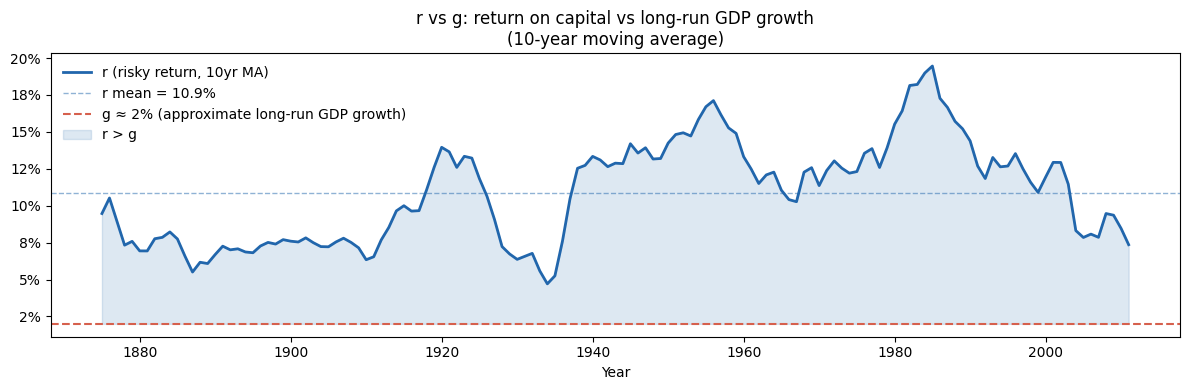

In [14]:
# Requires 'gdp_rtn' or growth variable — check if your dataset has it
# If not, this proxies r as the risky portfolio return

r = df_clean.groupby('year')['risky_tr'].mean()
smooth_r = r.rolling(10, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(smooth_r.index, smooth_r, color='#2166ac', lw=2, label='r (risky return, 10yr MA)')
ax.axhline(smooth_r.mean(), color='#2166ac', lw=1, linestyle='--', alpha=0.5,
           label=f'r mean = {smooth_r.mean()*100:.1f}%')
ax.axhline(0.02, color='#d6604d', lw=1.5, linestyle='--',
           label='g ≈ 2% (approximate long-run GDP growth)')
ax.fill_between(smooth_r.index, smooth_r, 0.02,
                where=smooth_r >= 0.02, color='#2166ac', alpha=0.15, label='r > g')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Year')
ax.set_title('r vs g: return on capital vs long-run GDP growth\n(10-year moving average)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The r vs g chart is one of the most important visualizations in modern macroeconomics, sparked by Thomas Piketty's Capital in the Twenty-First Century. The blue line shows the average real return on capital (r), here proxied as an equal-weighted mix of equity and housing returns, smoothed with a 10-year moving average across 16 advanced economies. The red line represents g, the approximate long-run real GDP growth rate of around 2% per year.

The core finding is stark: r has exceeded g in almost every decade since 1870, with the shaded blue region showing just how persistently wide that gap has been. The mean return on capital across the full sample sits around 10.9%, roughly five times the long-run growth rate of the economy. The notable exceptions are the wartime and interwar periods (roughly 1914–1945), where the gap narrowed or briefly closed, and the post-2000 period where returns softened. These exceptions are themselves telling: the mid-20th century period coincided almost exactly with the only sustained period in modern history when r and g came close to converging. The chart therefore offers a long-run empirical foundation for understanding the historical relationship between returns on capital and economic growth.